# Step 04 — Evaluation

**A Computer Vision Project — *Flow Matching as a Layer*** · Stage 2
University of Haifa

---

## Purpose

Assemble the first two of Stage 2's four results from the results steps 2 and 3
already saved. **Nothing is retrained and no rollout is re-run** — every number here comes off
disk, which is what guarantees the table, the plots and the per-run CSVs describe exactly the
same models.

| Result | Produced here |
| --- | --- |
| 1. Classification results — all five methods, $\Delta\mathrm{Acc}$, accuracy-vs-$K$ with error bars | sections 2–4 |
| 2. Training curves — both objectives, verifying stable training | section 5 |
| 3. Feature-space visualisations | step 5 |
| 4. Flow trajectories | step 5 |

## The five methods being compared

| # | Method | Source |
| --- | --- | --- |
| 1 | Stage 1 prototype baseline | `Stage_1/results/prototype_runs.csv` |
| 2 | Standard FM, $T = 4$ | step 2 |
| 3 | Standard FM, $T = 12$ | step 2 |
| 4 | Rolled-out FM, $T = 4$ | step 3 |
| 5 | Rolled-out FM, $T = 12$ | step 3 |

$\times$ 3 encoder/dataset combinations $\times$ 3 training sizes = **45 accuracy cells**.

## Sections

| # | Section |
| --- | --- |
| 1 | Setup — load every saved result |
| 2 | The complete accuracy table |
| 3 | Change relative to the baseline |
| 4 | Accuracy vs. training-set size |
| 5 | Training curves — both objectives |
| 6 | When does the FM layer help? |
| 7 | Save artefacts |
| 8 | Manifest |

## 1 · Setup — load every saved result

In [1]:
from __future__ import annotations

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cvlab.evaluation import format_mean_std, summarize_runs
from cvlab.plotting import ArtifactWriter, apply_style
from cvlabfm.paths import RESULTS_ROOT, STAGE1_ROOT, STAGE1_RESULTS, step_dirs

apply_style()
art = ArtifactWriter(*step_dirs("04_evaluation"))

COMBOS = [("resnet18", "DTD"), ("resnet18", "FGVC-Aircraft"), ("dinov2", "FGVC-Aircraft")]
ORDER = ["5", "10", "full"]
T_VALUES = [4, 12]

# Stage 1 baseline, per run so the spread is available too.
base_runs = pd.read_csv(STAGE1_RESULTS / "prototype_runs.csv")
base_runs["K"] = base_runs["K"].astype(str)
base_runs["test_acc"] *= 100

std_runs = pd.read_csv(RESULTS_ROOT / "standard_fm_runs.csv")
roll_runs = pd.read_csv(RESULTS_ROOT / "rolled_out_fm_runs.csv")
for df in (std_runs, roll_runs):
    df["K"] = df["K"].astype(str)

with open(RESULTS_ROOT / "standard_fm_curves.json") as f:
    std_curves = json.load(f)
with open(RESULTS_ROOT / "rolled_out_fm_curves.json") as f:
    roll_curves = json.load(f)

print(f"baseline runs : {len(base_runs):3d}")
print(f"standard FM   : {len(std_runs):3d} evaluations ({len(std_curves)} models)")
print(f"rolled-out FM : {len(roll_runs):3d} evaluations ({len(roll_curves)} models)")

baseline runs :  21
standard FM   :  54 evaluations (27 models)
rolled-out FM :  54 evaluations (54 models)


## 2 · The complete accuracy table

Top-1 accuracy on the **complete official test split**, mean ± std over 3 seeds. The Stage 1
full-data baseline is a single deterministic run (no subsampling left to vary), so it carries
no spread — every other cell does.

In [2]:
# Every mean +/- std in this project goes through Stage 1's `summarize_runs`, which is the
# single place the sample-vs-population standard deviation is decided (it uses ddof=1). This
# table aggregates the *same* baseline runs Stage 1 published, so computing the spread here
# by hand would risk quoting a different number for an identical experiment. All three
# frames are already in percent, hence scale=1.0.
GROUP = ["encoder", "dataset", "K"]
base_sum = summarize_runs(base_runs, GROUP, scale=1.0)
fm_sum = {tag: summarize_runs(df, GROUP + ["T"], scale=1.0)
          for tag, df in [("standard", std_runs), ("rolled_out", roll_runs)]}


def _one(frame, **where):
    # The single summary row matching `where` - asserting uniqueness rather than taking
    # .iloc[0], so a duplicated or missing run is a failure and not a silent wrong number.
    m = np.ones(len(frame), dtype=bool)
    for col, val in where.items():
        m &= (frame[col] == val).to_numpy()
    assert m.sum() == 1, f"expected 1 row for {where}, got {m.sum()}"
    return frame[m].iloc[0]


rows = []
for enc, ds in COMBOS:
    for K in ORDER:
        b = _one(base_sum, encoder=enc, dataset=ds, K=K)
        row = {"encoder": enc, "dataset": ds, "K": K,
               "baseline": b["mean"], "baseline_std": b["std"], "baseline_n": b["n_runs"]}
        for tag in ("standard", "rolled_out"):
            for T in T_VALUES:
                r = _one(fm_sum[tag], encoder=enc, dataset=ds, K=K, T=T)
                row[f"{tag}_T{T}"] = r["mean"]
                row[f"{tag}_T{T}_std"] = r["std"]
                row[f"{tag}_T{T}_n"] = r["n_runs"]
        rows.append(row)

table = pd.DataFrame(rows)
art.table(table, "accuracy_table_full")

# Readable form, formatted by Stage 1's `format_mean_std` so a single-run cell is *labelled*
# rather than shown with a meaningless spread.
pretty = table[["encoder", "dataset", "K"]].copy()
pretty["baseline"] = [format_mean_std(r.baseline, r.baseline_std, r.baseline_n)
                      for r in table.itertuples()]
for tag, label in [("standard", "std FM"), ("rolled_out", "roll FM")]:
    for T in T_VALUES:
        pretty[f"{label} T={T}"] = [
            format_mean_std(r[f"{tag}_T{T}"], r[f"{tag}_T{T}_std"], r[f"{tag}_T{T}_n"])
            for _, r in table.iterrows()]

art.table(pretty, "accuracy_table_readable")
pretty

  saved table -> tables/accuracy_table_full.csv  (9 rows)
  saved table -> tables/accuracy_table_readable.csv  (9 rows)


,encoder,dataset,K,baseline,std FM T=4,std FM T=12,roll FM T=4,roll FM T=12
0,resnet18,DTD,5,46.10 +/- 1.89,44.47 +/- 1.05,44.79 +/- 1.01,40.99 +/- 1.60,40.87 +/- 1.46
1,resnet18,DTD,10,51.67 +/- 1.33,50.11 +/- 0.86,50.34 +/- 0.66,44.77 +/- 1.58,45.32 +/- 1.23
2,resnet18,DTD,full,58.83 (1 run),59.59 +/- 0.61,59.56 +/- 0.68,55.85 +/- 0.47,55.82 +/- 0.32
3,resnet18,FGVC-Aircraft,5,16.46 +/- 0.39,18.81 +/- 1.01,18.94 +/- 1.02,16.77 +/- 0.84,17.03 +/- 0.87
4,resnet18,FGVC-Aircraft,10,20.19 +/- 1.14,23.68 +/- 0.39,23.91 +/- 0.32,20.34 +/- 0.53,20.09 +/- 0.24
5,resnet18,FGVC-Aircraft,full,25.47 (1 run),31.04 +/- 0.93,30.97 +/- 0.56,25.64 +/- 1.72,25.28 +/- 1.69
6,dinov2,FGVC-Aircraft,5,23.79 +/- 0.47,33.30 +/- 0.68,32.82 +/- 0.57,34.13 +/- 0.59,33.86 +/- 0.58
7,dinov2,FGVC-Aircraft,10,27.74 +/- 0.98,43.27 +/- 1.09,42.48 +/- 1.16,45.42 +/- 1.10,45.35 +/- 0.83
8,dinov2,FGVC-Aircraft,full,34.26 (1 run),56.52 +/- 0.27,55.70 +/- 0.31,52.05 +/- 0.91,52.08 +/- 0.82


### Cross-check: does this table agree with steps 2 and 3?

This table re-derives numbers that steps 2 and 3 already published. Re-deriving anything is
an opportunity to disagree with the original — a different aggregation convention here would
produce a table that quietly contradicts the two notebooks it summarises, and nothing in the
output would look wrong. The check below fails loudly instead.

In [3]:
step2 = pd.read_csv(step_dirs("02_standard_fm", create=False)[1] / "accuracy_summary.csv")
step3 = pd.read_csv(step_dirs("03_rolled_out_fm", create=False)[1] / "accuracy_summary.csv")
for df in (step2, step3):
    df["K"] = df["K"].astype(str)

mismatches = []
for tag, src in [("standard", step2), ("rolled_out", step3)]:
    for r in table.itertuples():
        for T in T_VALUES:
            up = src[(src.encoder == r.encoder) & (src.dataset == r.dataset)
                     & (src.K == r.K) & (src["T"] == T)]
            assert len(up) == 1, f"{tag} {r.encoder}/{r.dataset}/K={r.K}/T={T}: {len(up)} rows"
            up = up.iloc[0]
            for field, mine in [("mean", getattr(r, f"{tag}_T{T}")),
                                ("std", getattr(r, f"{tag}_T{T}_std"))]:
                if abs(float(up[field]) - float(mine)) > 0.005:
                    mismatches.append((tag, r.encoder, r.dataset, r.K, T, field,
                                       float(up[field]), float(mine)))

n = len(table) * len(T_VALUES) * 2 * 2
print(f"compared {n} values against the upstream step tables")
for m in mismatches:
    print(f"  MISMATCH {m}")
assert not mismatches, f"{len(mismatches)} cells disagree with steps 2-3"
print("all agree")

# And the baseline column must agree with the Stage 1 table it was taken from.
s1 = pd.read_csv(STAGE1_ROOT / "Work" / "04_prototypes" / "tables" / "accuracy_summary.csv")
s1["K"] = s1["K"].astype(str)
for r in table.itertuples():
    up = s1[(s1.encoder == r.encoder) & (s1.dataset == r.dataset) & (s1.K == r.K)].iloc[0]
    assert abs(up["mean"] - r.baseline) <= 0.005, (r.encoder, r.dataset, r.K, "mean")
    both_nan = pd.isna(up["std"]) and pd.isna(r.baseline_std)
    assert both_nan or abs(up["std"] - r.baseline_std) <= 0.005, \
        f"{r.encoder}/{r.dataset}/K={r.K}: Stage 1 published {up['std']}, this table has {r.baseline_std}"
print(f"all {len(table)} baseline cells match the Stage 1 table they came from")

compared 72 values against the upstream step tables
all agree
all 9 baseline cells match the Stage 1 table they came from


## 3 · Change relative to the baseline

$\Delta\mathrm{Acc} = \mathrm{Acc}_\mathrm{FM} - \mathrm{Acc}_\mathrm{baseline}$, against the
same combination and the same $K$.

In [4]:
delta = table[["encoder", "dataset", "K"]].copy()
for tag, label in [("standard", "std FM"), ("rolled_out", "roll FM")]:
    for T in T_VALUES:
        delta[f"{label} T={T}"] = (table[f"{tag}_T{T}"] - table["baseline"]).round(2)

art.table(delta, "delta_vs_baseline")

best = delta[[c for c in delta.columns if "FM" in c]].max().max()
worst = delta[[c for c in delta.columns if "FM" in c]].min().min()
n_pos = (delta[[c for c in delta.columns if "FM" in c]] > 0).sum().sum()
print(f"{n_pos} of 36 FM cells improve on the baseline "
      f"(best {best:+.2f} pp, worst {worst:+.2f} pp)")
delta

  saved table -> tables/delta_vs_baseline.csv  (9 rows)
24 of 36 FM cells improve on the baseline (best +22.26 pp, worst -6.90 pp)


,encoder,dataset,K,std FM T=4,std FM T=12,roll FM T=4,roll FM T=12
0,resnet18,DTD,5,-1.63,-1.31,-5.11,-5.23
1,resnet18,DTD,10,-1.56,-1.33,-6.90,-6.35
2,resnet18,DTD,full,0.76,0.73,-2.98,-3.01
3,resnet18,FGVC-Aircraft,5,2.35,2.48,0.31,0.57
4,resnet18,FGVC-Aircraft,10,3.49,3.72,0.15,-0.10
5,resnet18,FGVC-Aircraft,full,5.57,5.50,0.17,-0.19
6,dinov2,FGVC-Aircraft,5,9.51,9.03,10.34,10.07
7,dinov2,FGVC-Aircraft,10,15.53,14.74,17.68,17.61
8,dinov2,FGVC-Aircraft,full,22.26,21.44,17.79,17.82


  saved plot  -> plots/delta_vs_baseline.png


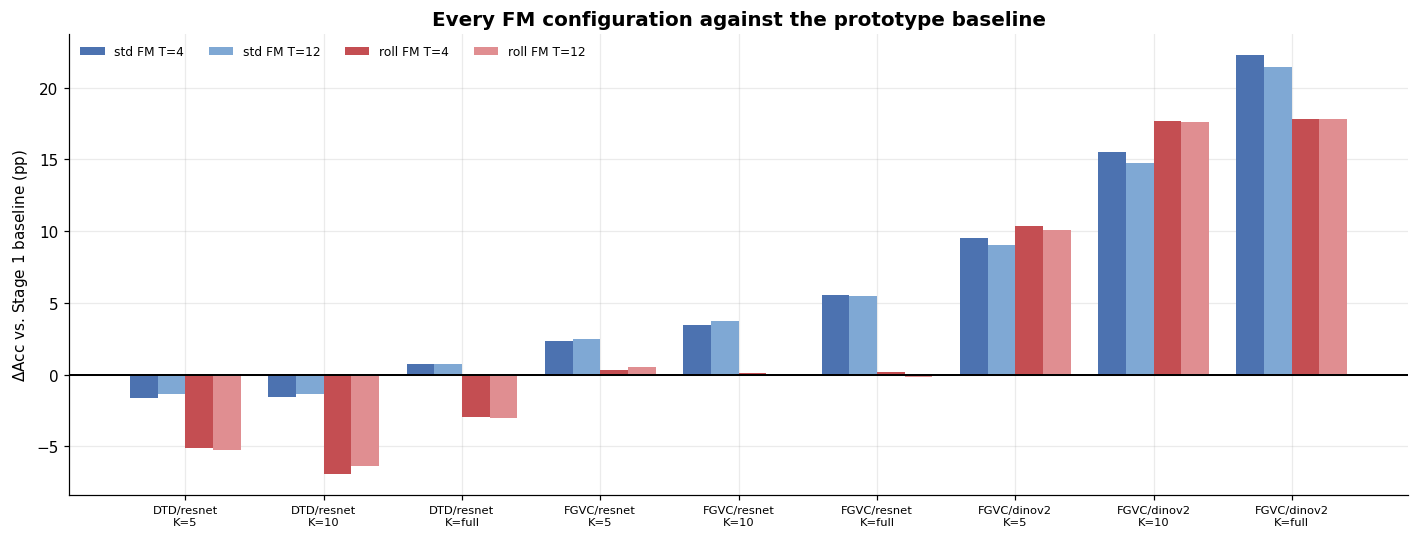

In [5]:
fig, ax = plt.subplots(figsize=(13, 5.0))

methods = [("std FM T=4", "#4C72B0"), ("std FM T=12", "#7FA8D4"),
           ("roll FM T=4", "#C44E52"), ("roll FM T=12", "#E08E91")]
labels = [f"{d[:4]}/{e[:6]}\nK={k}" for e, d in COMBOS for k in ORDER]
x = np.arange(len(labels))
width = 0.2

for i, (m, c) in enumerate(methods):
    vals = delta[m].values
    ax.bar(x + (i - 1.5) * width, vals, width, color=c, label=m)

ax.axhline(0, color="black", lw=1.3)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylabel(r"$\Delta$Acc vs. Stage 1 baseline (pp)")
ax.set_title("Every FM configuration against the prototype baseline",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=8, ncol=4)
fig.tight_layout()
art.figure(fig, "delta_vs_baseline")
plt.show()

## 4 · Accuracy vs. training-set size

Accuracy versus $K$, with error bars, all five methods overlaid.

  saved plot  -> plots/accuracy_vs_k.png


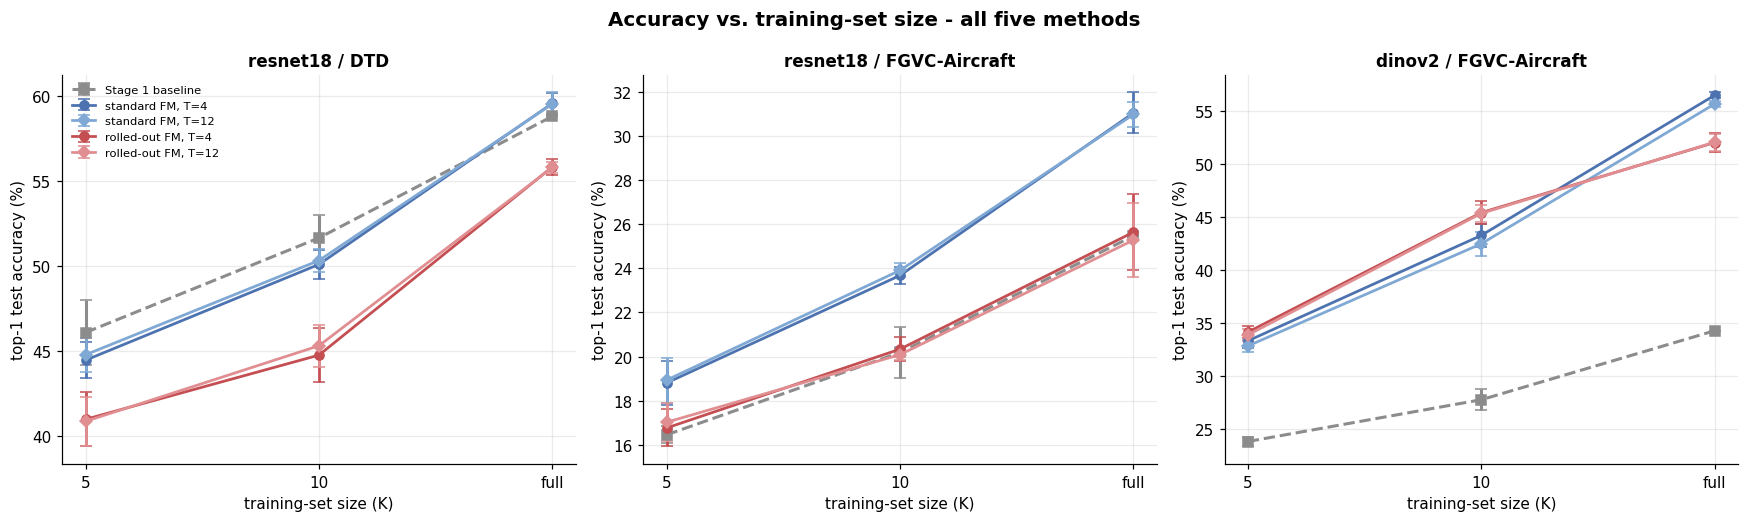

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

for ax, (enc, ds) in zip(axes, COMBOS):
    sel = table[(table.encoder == enc) & (table.dataset == ds)].set_index("K").loc[ORDER]

    ax.errorbar(ORDER, sel["baseline"],
                yerr=sel["baseline_std"].fillna(0.0),
                marker="s", ls="--", lw=2.0, capsize=4, color="#8C8C8C",
                label="Stage 1 baseline")
    for tag, label, colors in [("standard", "standard FM", ["#4C72B0", "#7FA8D4"]),
                                ("rolled_out", "rolled-out FM", ["#C44E52", "#E08E91"])]:
        for T, c in zip(T_VALUES, colors):
            ax.errorbar(ORDER, sel[f"{tag}_T{T}"], yerr=sel[f"{tag}_T{T}_std"],
                        marker="o" if T == 4 else "D", capsize=4, lw=1.8, color=c,
                        label=f"{label}, T={T}")

    ax.set_title(f"{enc} / {ds}", fontsize=11)
    ax.set_xlabel("training-set size (K)")
    ax.set_ylabel("top-1 test accuracy (%)")
    if ax is axes[0]:
        ax.legend(fontsize=7.5)

fig.suptitle("Accuracy vs. training-set size - all five methods",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "accuracy_vs_k")
plt.show()

## 5 · Training curves — both objectives

These curves verify that training is stable and that both approaches reach
reasonable solutions.

**The two curves must not be compared to each other.** Standard FM measures velocity error at
a randomly sampled time; rolled-out measures endpoint distance after $T$ steps. They are
different quantities on different scales — each is only meaningful against itself, which is
why they are drawn on separate axes rather than overlaid.

  saved plot  -> plots/training_curves.png


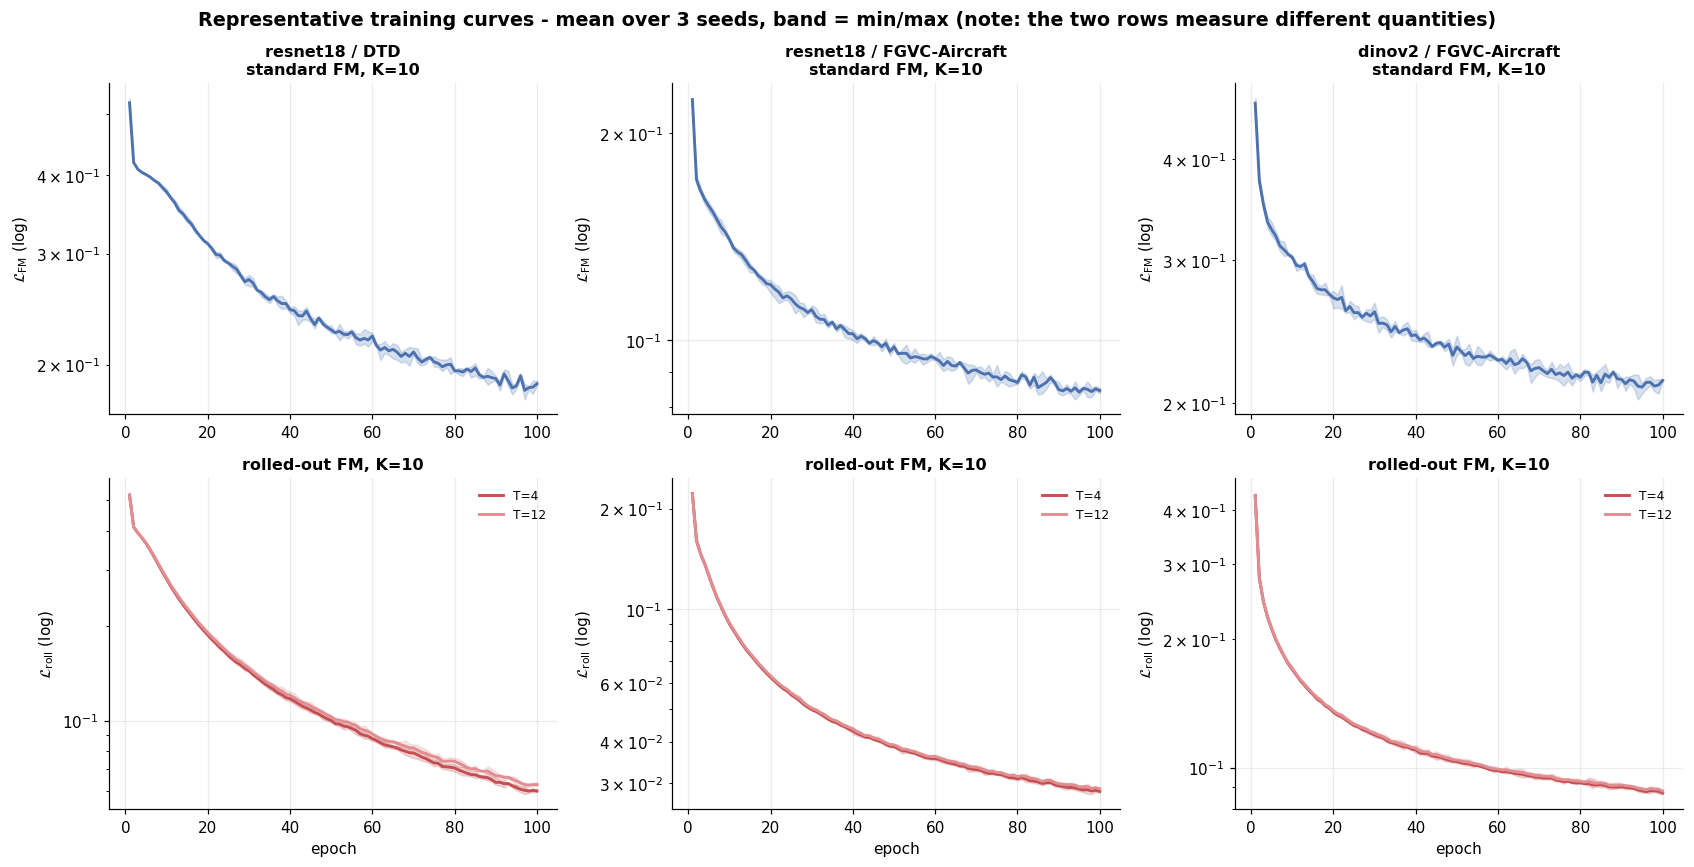

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15.5, 8))
REPR_K = "10"          # the middle setting: noisier than full, less erratic than 5-shot

for col, (enc, ds) in enumerate(COMBOS):
    # Top row: standard FM (one model serves both T).
    ax = axes[0, col]
    hist = np.array([std_curves[f"{enc}__{ds}__K{REPR_K}__seed{s}"] for s in (0, 1, 2)])
    ep = np.arange(1, hist.shape[1] + 1)
    ax.plot(ep, hist.mean(0), color="#4C72B0", lw=1.9)
    ax.fill_between(ep, hist.min(0), hist.max(0), color="#4C72B0", alpha=0.22)
    ax.set_yscale("log")
    ax.set_ylabel(r"$\mathcal{L}_{\mathrm{FM}}$ (log)")
    ax.set_title(f"{enc} / {ds}\nstandard FM, K={REPR_K}", fontsize=10.5)

    # Bottom row: rolled-out, one curve per T.
    ax = axes[1, col]
    for T, c in zip(T_VALUES, ["#C44E52", "#E08E91"]):
        hist = np.array([roll_curves[f"{enc}__{ds}__K{REPR_K}__seed{s}__T{T}"]
                         for s in (0, 1, 2)])
        ax.plot(ep, hist.mean(0), color=c, lw=1.9, label=f"T={T}")
        ax.fill_between(ep, hist.min(0), hist.max(0), color=c, alpha=0.22)
    ax.set_yscale("log")
    ax.set_xlabel("epoch")
    ax.set_ylabel(r"$\mathcal{L}_{\mathrm{roll}}$ (log)")
    ax.set_title(f"rolled-out FM, K={REPR_K}", fontsize=10.5)
    ax.legend(fontsize=8)

fig.suptitle("Representative training curves - mean over 3 seeds, band = min/max "
             "(note: the two rows measure different quantities)",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
art.figure(fig, "training_curves")
plt.show()

In [8]:
# Convergence summary across every model in both steps, so "training is stable" is a
# measured claim rather than a visual impression.
conv_rows = []
for tag, curves, keys in [
        ("standard FM", std_curves, [(e, d, k, s, None) for e, d in COMBOS
                                      for k in ORDER for s in (0, 1, 2)]),
        ("rolled-out FM", roll_curves, [(e, d, k, s, T) for e, d in COMBOS
                                         for k in ORDER for s in (0, 1, 2)
                                         for T in T_VALUES])]:
    finals, reductions = [], []
    for enc, ds, K, seed, T in keys:
        key = (f"{enc}__{ds}__K{K}__seed{seed}"
               + (f"__T{T}" if T is not None else ""))
        h = np.array(curves[key])
        finals.append(h[-1])
        reductions.append((h[0] - h[-1]) / h[0] * 100)
    conv_rows.append({
        "objective": tag,
        "models": len(keys),
        "final_loss_min": round(float(np.min(finals)), 5),
        "final_loss_max": round(float(np.max(finals)), 5),
        "loss_reduction_min_%": round(float(np.min(reductions)), 1),
        "loss_reduction_max_%": round(float(np.max(reductions)), 1),
        "diverged": int(sum(1 for f in finals if not np.isfinite(f) or f > 1.0)),
    })

convergence = pd.DataFrame(conv_rows)
art.table(convergence, "convergence_summary")
convergence

  saved table -> tables/convergence_summary.csv  (2 rows)


,objective,models,final_loss_min,final_loss_max,loss_reduction_min_%,loss_reduction_max_%,diverged
0,standard FM,27,0.07834,0.21366,53.9,71.5,0
1,rolled-out FM,54,0.02155,0.08930,79.4,92.9,0


## 6 · When does the FM layer help?

The gains are not uniform — they range from $-6.9$ pp to $+22.3$ pp. Stage 1 measured a
**separability margin** for each encoder/dataset before any classifier was trained
(mean cosine to the own class centroid minus mean cosine to other centroids). Plotting the FM
gain against it tests whether the benefit is predictable from the feature geometry alone.

In [9]:
sep = pd.read_csv(STAGE1_ROOT / "Work/02_feature_extraction/tables/class_separability.csv")
sep_map = {(r.encoder, r.dataset): r.separability_margin for _, r in sep.iterrows()}

gain_rows = []
for enc, ds in COMBOS:
    for K in ORDER:
        row = table[(table.encoder == enc) & (table.dataset == ds) & (table.K == K)].iloc[0]
        gain_rows.append({
            "encoder": enc, "dataset": ds, "K": K,
            "separability_margin": sep_map[(enc, ds)],
            "baseline": row.baseline,
            "best_fm": max(row[f"{t}_T{T}"] for t in ("standard", "rolled_out")
                           for T in T_VALUES),
        })

gains = pd.DataFrame(gain_rows)
gains["gain_pp"] = (gains.best_fm - gains.baseline).round(2)
art.table(gains, "gain_vs_separability")
gains

  saved table -> tables/gain_vs_separability.csv  (9 rows)


,encoder,dataset,K,separability_margin,baseline,best_fm,gain_pp
0,resnet18,DTD,5,0.1715,46.10,44.79,-1.31
1,resnet18,DTD,10,0.1715,51.67,50.34,-1.33
2,resnet18,DTD,full,0.1715,58.83,59.59,0.76
3,resnet18,FGVC-Aircraft,5,0.0411,16.46,18.94,2.48
4,resnet18,FGVC-Aircraft,10,0.0411,20.19,23.91,3.72
5,resnet18,FGVC-Aircraft,full,0.0411,25.47,31.04,5.57
6,dinov2,FGVC-Aircraft,5,0.4201,23.79,34.13,10.34
7,dinov2,FGVC-Aircraft,10,0.4201,27.74,45.42,17.68
8,dinov2,FGVC-Aircraft,full,0.4201,34.26,56.52,22.26


  saved plot  -> plots/gain_analysis.png


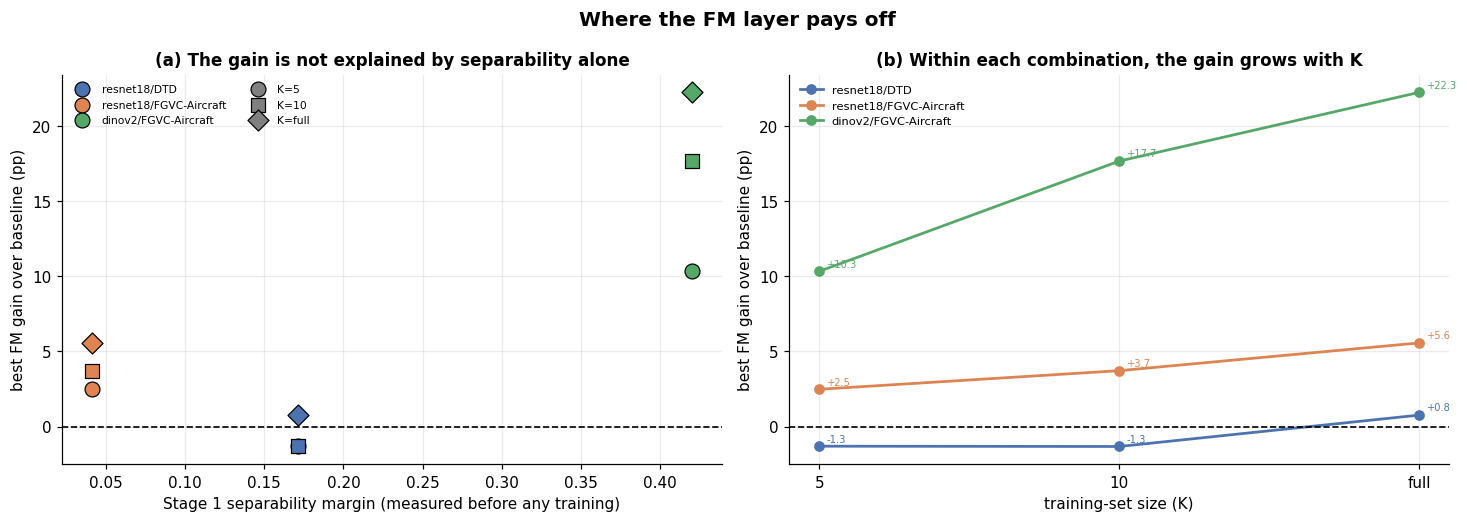

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

# (a) gain against the pre-measured separability of the features
ax = axes[0]
markers = {"5": "o", "10": "s", "full": "D"}
for (enc, ds), grp in gains.groupby(["encoder", "dataset"], sort=False):
    for _, r in grp.iterrows():
        ax.scatter(r.separability_margin, r.gain_pp, s=95, marker=markers[r.K],
                   edgecolor="black", linewidth=0.8,
                   color={"resnet18DTD": "#4C72B0", "resnet18FGVC-Aircraft": "#DD8452",
                          "dinov2FGVC-Aircraft": "#55A868"}[enc + ds], zorder=3)
ax.axhline(0, color="black", lw=1.1, ls="--")
for enc, ds in COMBOS:
    ax.scatter([], [], s=95, edgecolor="black", linewidth=0.8, label=f"{enc}/{ds}",
               color={"resnet18DTD": "#4C72B0", "resnet18FGVC-Aircraft": "#DD8452",
                      "dinov2FGVC-Aircraft": "#55A868"}[enc + ds])
for k, m in markers.items():
    ax.scatter([], [], marker=m, s=95, color="grey", edgecolor="black",
               linewidth=0.8, label=f"K={k}")
ax.set_xlabel("Stage 1 separability margin (measured before any training)")
ax.set_ylabel("best FM gain over baseline (pp)")
ax.set_title("(a) The gain is not explained by separability alone", fontsize=11)
ax.legend(fontsize=7, ncol=2)

# (b) how the gain moves with training-set size, within each combination
ax = axes[1]
for (enc, ds), grp in gains.groupby(["encoder", "dataset"], sort=False):
    c = {"resnet18DTD": "#4C72B0", "resnet18FGVC-Aircraft": "#DD8452",
         "dinov2FGVC-Aircraft": "#55A868"}[enc + ds]
    grp = grp.set_index("K").loc[ORDER].reset_index()
    ax.plot(grp.K, grp.gain_pp, marker="o", lw=1.8, color=c, label=f"{enc}/{ds}")
    for _, r in grp.iterrows():
        ax.annotate(f"{r.gain_pp:+.1f}", (r.K, r.gain_pp), fontsize=6.5,
                    xytext=(5, 3), textcoords="offset points", color=c)
ax.axhline(0, color="black", lw=1.1, ls="--")
ax.set_xlabel("training-set size (K)")
ax.set_ylabel("best FM gain over baseline (pp)")
ax.set_title("(b) Within each combination, the gain grows with K", fontsize=11)
ax.legend(fontsize=7.5)

fig.suptitle("Where the FM layer pays off", fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "gain_analysis")
plt.show()

## 6b - What actually predicts the gain: headroom to a trained probe

Separability does not order the gains, and $K$ only orders them *within* a combination. There
is a third quantity Stage 1 already measured that does order all nine cells at once: the
**headroom** between the prototype baseline and the *trained linear probe* on the same cell.

$$\mathrm{headroom} = \mathrm{Acc}_\mathrm{probe} - \mathrm{Acc}_\mathrm{prototype}$$

This asks how much accuracy was being left on the table by not training a classifier at all.
If the FM layer is recovering some of what a trained classifier would have given, the gain
should track it.

In [11]:
probe = pd.read_csv(STAGE1_ROOT / "Work/05_analysis/tables/combined_accuracy_table.csv")
probe["K"] = probe["K"].astype(str)

head_rows = []
for enc, ds in COMBOS:
    for K in ORDER:
        row = table[(table.encoder == enc) & (table.dataset == ds) & (table.K == K)].iloc[0]
        g = probe[(probe.encoder == enc) & (probe.dataset == ds) & (probe.K == K)]
        lp = float(g[g.method == "linear_probe"]["mean"].iloc[0])
        head_rows.append({
            "encoder": enc, "dataset": ds, "K": K,
            "prototype": row.baseline, "linear_probe": lp,
            "headroom": round(lp - row.baseline, 2),
            "gain_standard": round(row.standard_T4 - row.baseline, 2),
            "gain_rolled_out": round(row.rolled_out_T4 - row.baseline, 2),
        })

headroom = pd.DataFrame(head_rows).sort_values("headroom").reset_index(drop=True)
headroom["recovered_pct"] = (100 * headroom.gain_standard / headroom.headroom).round(0)
# The fraction is meaningless where there was essentially no gap to recover, so it is only
# reported where the probe led the prototype by more than 2 pp.
headroom.loc[headroom.headroom <= 2.0, "recovered_pct"] = np.nan
art.table(headroom, "gain_vs_headroom")
headroom

  saved table -> tables/gain_vs_headroom.csv  (9 rows)


,encoder,dataset,K,prototype,linear_probe,headroom,gain_standard,gain_rolled_out,recovered_pct
0,resnet18,DTD,5,46.10,44.86,-1.24,-1.63,-5.11,NaN
1,resnet18,DTD,10,51.67,52.04,0.37,-1.56,-6.90,NaN
2,resnet18,DTD,full,58.83,62.82,3.99,0.76,-2.98,19.0
3,resnet18,FGVC-Aircraft,5,16.46,20.76,4.30,2.35,0.31,55.0
4,resnet18,FGVC-Aircraft,10,20.19,27.87,7.68,3.49,0.15,45.0
5,resnet18,FGVC-Aircraft,full,25.47,38.15,12.68,5.57,0.17,44.0
6,dinov2,FGVC-Aircraft,5,23.79,38.19,14.40,9.51,10.34,66.0
7,dinov2,FGVC-Aircraft,10,27.74,51.54,23.80,15.53,17.68,65.0
8,dinov2,FGVC-Aircraft,full,34.26,67.55,33.29,22.26,17.79,67.0


In [12]:
from scipy import stats

fit = stats.linregress(headroom.headroom, headroom.gain_standard)
rho = stats.spearmanr(headroom.headroom, headroom.gain_standard)
print(f"standard FM:   Pearson r = {fit.rvalue:.3f}   R^2 = {fit.rvalue**2:.3f}   "
      f"Spearman rho = {rho.statistic:.3f}")
print(f"fit:           gain = {fit.slope:.3f} x headroom {fit.intercept:+.2f}")
print(f"break-even:    headroom = {-fit.intercept / fit.slope:.2f} pp")
fit_roll = stats.linregress(headroom.headroom, headroom.gain_rolled_out)
print(f"rolled-out FM: Pearson r = {fit_roll.rvalue:.3f}   R^2 = {fit_roll.rvalue**2:.3f}")

standard FM:   Pearson r = 0.994   R^2 = 0.988   Spearman rho = 1.000
fit:           gain = 0.708 x headroom -1.56
break-even:    headroom = 2.20 pp
rolled-out FM: Pearson r = 0.944   R^2 = 0.891


  saved plot  -> plots/gain_vs_headroom.png


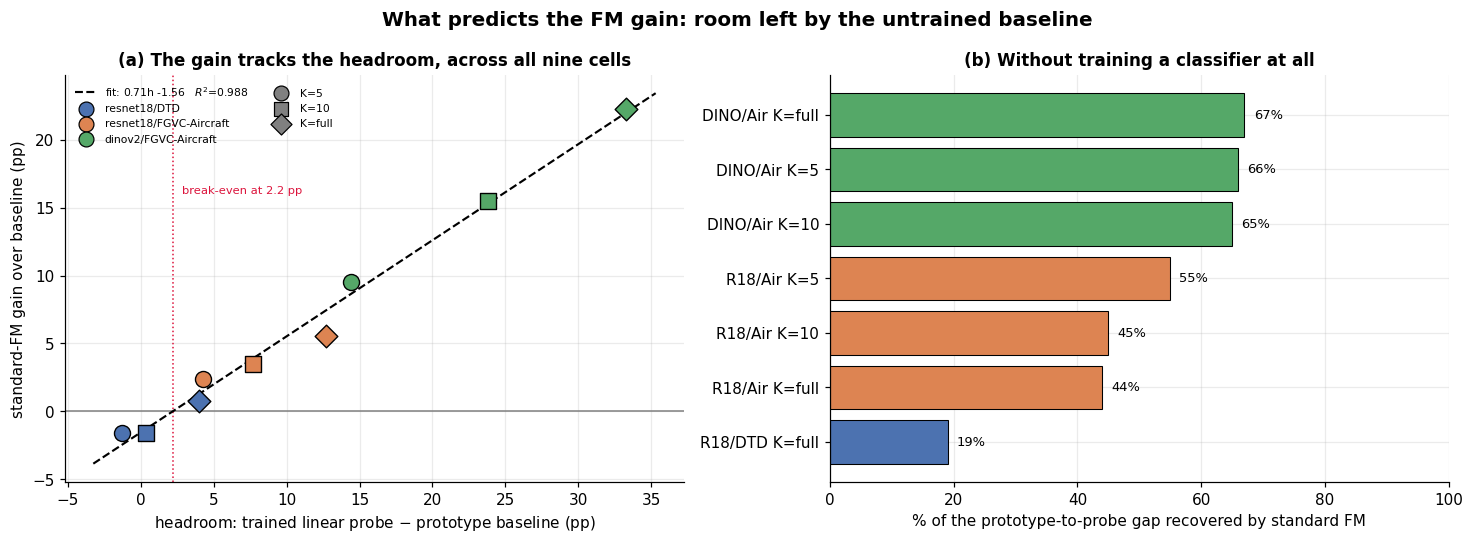

In [13]:
COL = {"resnet18DTD": "#4C72B0", "resnet18FGVC-Aircraft": "#DD8452",
       "dinov2FGVC-Aircraft": "#55A868"}
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

# (a) the relationship itself
ax = axes[0]
xs = np.linspace(headroom.headroom.min() - 2, headroom.headroom.max() + 2, 50)
ax.plot(xs, fit.slope * xs + fit.intercept, color="black", lw=1.4, ls="--", zorder=2,
        label=f"fit: {fit.slope:.2f}h {fit.intercept:+.2f}   $R^2$={fit.rvalue**2:.3f}")
ax.axhline(0, color="grey", lw=1.0, zorder=1)
ax.axvline(-fit.intercept / fit.slope, color="crimson", lw=1.0, ls=":", zorder=1)
ax.annotate(f"break-even at {-fit.intercept / fit.slope:.1f} pp",
            (-fit.intercept / fit.slope, headroom.gain_standard.max() * 0.72),
            fontsize=7.5, color="crimson", ha="left", xytext=(6, 0),
            textcoords="offset points")
markers = {"5": "o", "10": "s", "full": "D"}
for r in headroom.itertuples():
    ax.scatter(r.headroom, r.gain_standard, s=110, marker=markers[r.K], zorder=4,
               color=COL[r.encoder + r.dataset], edgecolor="black", linewidth=0.9)
for enc, ds in COMBOS:
    ax.scatter([], [], s=95, color=COL[enc + ds], edgecolor="black", linewidth=0.8,
               label=f"{enc}/{ds}")
for k, m in markers.items():
    ax.scatter([], [], marker=m, s=95, color="grey", edgecolor="black", linewidth=0.8,
               label=f"K={k}")
ax.set_xlabel("headroom: trained linear probe $-$ prototype baseline (pp)")
ax.set_ylabel("standard-FM gain over baseline (pp)")
ax.set_title("(a) The gain tracks the headroom, across all nine cells", fontsize=11)
ax.legend(fontsize=7, ncol=2, loc="upper left")

# (b) how much of that headroom the flow actually recovers
ax = axes[1]
sel = headroom[headroom.recovered_pct.notna()].sort_values("recovered_pct")
labels = [f"{r.encoder.replace('resnet18', 'R18').replace('dinov2', 'DINO')}/"
          f"{r.dataset.replace('FGVC-Aircraft', 'Air')} K={r.K}" for r in sel.itertuples()]
bars = ax.barh(labels, sel.recovered_pct,
               color=[COL[r.encoder + r.dataset] for r in sel.itertuples()],
               edgecolor="black", linewidth=0.7)
for b, v in zip(bars, sel.recovered_pct):
    ax.text(v + 1.5, b.get_y() + b.get_height() / 2, f"{v:.0f}%", va="center", fontsize=8.5)
ax.set_xlim(0, 100)
ax.set_xlabel("% of the prototype-to-probe gap recovered by standard FM")
ax.set_title("(b) Without training a classifier at all", fontsize=11)

fig.suptitle("What predicts the FM gain: room left by the untrained baseline",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "gain_vs_headroom")
plt.show()

**This orders every cell.** Spearman $
ho = 1.000$ -- the nine cells rank identically by
headroom and by gain -- with $R^2 = 0.988$ on the linear fit. Neither separability nor $K$
comes close to that.

**It also explains the failures**, which is the stronger test. The fit crosses zero at a
headroom of about **2.2 pp**: below that the FM layer costs more than it recovers. ResNet-18 /
DTD at $K = 5$ and $K = 10$ are the only two cells beneath it -- the prototype baseline there
is already level with (at $K = 5$, slightly *ahead* of) the trained probe, so there is nothing
for a transport to recover and the layer is pure overhead. Those are exactly the two cells
where FM loses.

**Read plainly:** the FM layer recovers roughly **70 %** of whatever a trained linear probe
would have gained over the prototype baseline, minus a fixed cost of about 1.6 pp -- while
keeping the prototype structure and training no classifier.

Two honest caveats. Nine cells is a small sample, and the linear probe is a *reference point*
rather than a mechanism -- this says the flow captures most of what a trained classifier
would, not why. Both are worth stating before the relationship is leaned on.

**Reading (a).** Separability alone does not order the gains. DINOv2/Aircraft has the widest
margin (0.420) *and* the largest gain, but ResNet-18/DTD has the second-widest (0.172) and the
*smallest* gain — while ResNet-18/Aircraft, with the narrowest margin (0.041), sits in
between. A single pre-training geometry number is not sufficient to predict the benefit.

**Reading (b).** The one pattern that holds without exception is **within** each combination:
the gain grows monotonically with $K$. More training features give the velocity field more to
fit, and the flow is the only component that has parameters to fit them with — the prototype
baseline is a fixed average and cannot exploit extra data the same way. On DTD this is what
turns a $-1.6$ pp deficit at $K = 5$ into $+0.8$ pp at full data.

**What does *not* explain the ordering across combinations.** "The FM layer helps most where
the baseline was weakest" is tempting but false: ResNet-18/Aircraft has the *weakest*
baselines of all (16–25 %) and gains only 2.5–5.6 pp, while DINOv2/Aircraft starts higher
(24–34 %) and gains 10–22 pp. The encoder matters more than the baseline's headroom — DINOv2
features carry structure a learned transport can exploit that ResNet-18's, on this dataset, do
not.

## 7 · Save artefacts

In [14]:
combined = pd.concat([
    base_runs.assign(method="prototype_baseline", T=np.nan)[
        ["encoder", "dataset", "K", "seed", "T", "method", "test_acc"]],
    std_runs.assign(method="standard_fm")[
        ["encoder", "dataset", "K", "seed", "T", "method", "test_acc"]],
    roll_runs.assign(method="rolled_out_fm")[
        ["encoder", "dataset", "K", "seed", "T", "method", "test_acc"]],
], ignore_index=True)

combined.to_csv(RESULTS_ROOT / "all_runs_combined.csv", index=False)
print(f"  results/all_runs_combined.csv   {len(combined)} rows "
      f"({(RESULTS_ROOT / 'all_runs_combined.csv').stat().st_size / 1024:.1f} KB)")

methodology = pd.DataFrame([
    {"item": "scope", "value": "results 1 (classification results) and 2 (training curves)"},
    {"item": "computation", "value": "none - every number read from steps 2-3 saved results"},
    {"item": "methods compared", "value": "5: baseline, standard FM T=4/12, rolled-out FM T=4/12"},
    {"item": "cells", "value": "45 = 3 combos x 3 K x 5 methods"},
    {"item": "metric", "value": "top-1 accuracy, complete official test split"},
    {"item": "repetition", "value": "mean +/- std over 3 seeds (baseline full-data is 1 deterministic run)"},
    {"item": "loss comparability", "value": "standard and rolled-out losses measure different quantities - never compared"},
])
art.table(methodology, "methodology")
methodology

  results/all_runs_combined.csv   129 rows (8.0 KB)
  saved table -> tables/methodology.csv  (7 rows)


,item,value
0,scope,results 1 (classification results) and 2 (trai...
1,computation,none - every number read from steps 2-3 saved ...
2,methods compared,"5: baseline, standard FM T=4/12, rolled-out FM..."
3,cells,45 = 3 combos x 3 K x 5 methods
4,metric,"top-1 accuracy, complete official test split"
5,repetition,mean +/- std over 3 seeds (baseline full-data ...
6,loss comparability,standard and rolled-out losses measure differe...


## 8 · Manifest

In [15]:
art.manifest()

12 artefacts in C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_2\Work\04_evaluation


,kind,file,size_KB
0,plot,plots/accuracy_vs_k.png,171.0
1,plot,plots/delta_vs_baseline.png,38.8
2,plot,plots/gain_analysis.png,95.7
3,plot,plots/gain_vs_headroom.png,113.8
4,plot,plots/training_curves.png,220.0
5,table,tables/accuracy_table_full.csv,1.0
6,table,tables/accuracy_table_readable.csv,0.9
7,table,tables/convergence_summary.csv,0.2
8,table,tables/delta_vs_baseline.csv,0.5
9,table,tables/gain_vs_headroom.csv,0.6


---

## Next step

**Step 5 — Visualisations.** The remaining two results: feature-space
comparisons (original encoder features vs. after standard FM vs. after rolled-out FM, same
test examples, same class colours, projection fitted jointly across the compared sets), and
flow trajectories showing intermediate states between the original feature and its prototype.